# Import Libraries

In [1]:
import os
import json
import csv
import random
from pathlib import Path

# Data Science & Visualization
import numpy as np
import pandas as pd  # Often useful with CSVs
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Computer Vision
import cv2

# Scikit-Learn (Metrics & Preprocessing)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, roc_curve, auc, confusion_matrix, 
    classification_report, mean_absolute_error, 
    mean_squared_error, r2_score
)

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras import layers, models, Input, Model, regularizers
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import Dense, Flatten, Concatenate, Layer

In [2]:
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

# Data Prepration

## Data Loading

In [3]:
Dataset_path = "Data" 
IMG_SIZE = 224

In [4]:
def load_dataset(Dataset_path):
    X_palm, X_nail, X_meta = [], [], []
    y_hb                    = []
    subject_ids             = []

    root     = Path(Dataset_path)
    subjects = [p for p in root.iterdir() if p.is_dir()]

    for s in subjects:
        json_path = s / "info.json"
        if not json_path.exists():
            continue
        with open(json_path, "r") as f:
            info = json.load(f)

        age    = info["age"]
        gender = 1 if info["gender"] == "Male" else 0
        hb     = float(info["HB_Level"])

        # Palm ROI
        palm_path = s / "Palm_ROI" / "frame_03.jpg"
        if not palm_path.exists():
            continue
        palm_img = cv2.imread(str(palm_path))
        if palm_img is None:
            continue
        palm_img = cv2.cvtColor(palm_img, cv2.COLOR_BGR2RGB)
        palm_img = cv2.resize(palm_img, (IMG_SIZE, IMG_SIZE))
        palm_img = palm_img / 255.0

        # Nail ROI + background removal
        nail_path = s / "nail_roi.jpg"
        if not nail_path.exists():
            continue
        nail_img = cv2.imread(str(nail_path))
        if nail_img is None:
            continue
        
        nail_img = cv2.cvtColor(nail_img, cv2.COLOR_BGR2RGB)
        nail_img = cv2.resize(nail_img, (IMG_SIZE, IMG_SIZE))
        nail_img = nail_img / 255.0

        X_palm.append(palm_img)
        X_nail.append(nail_img)
        X_meta.append([age, gender])
        y_hb.append(hb)
        subject_ids.append(s.name)

    return (
        np.array(X_palm,  dtype=np.float32),
        np.array(X_nail,  dtype=np.float32),
        np.array(X_meta,  dtype=np.float32),
        np.array(y_hb,    dtype=np.float32),
        np.array(subject_ids)
    )

In [5]:
X_palm, X_nail, X_meta, y_hb, subject_ids = load_dataset(Dataset_path)

## Data Split

In [6]:
unique_subjects = np.unique(subject_ids)
unique_labels = np.array([
    0 if y_hb[subject_ids == s][0] >= 12.0 else 1 
    for s in unique_subjects
])

train_subj, temp_subj = train_test_split(
    unique_subjects, test_size=0.30, random_state=42, stratify=unique_labels
)
temp_labels = np.array([
    0 if y_hb[subject_ids == s][0] >= 12.0 else 1 
    for s in temp_subj
])
val_subj, test_subj = train_test_split(
    temp_subj, test_size=0.50, random_state=42, stratify=temp_labels
)

train_idx = np.where(np.isin(subject_ids, train_subj))[0]
val_idx   = np.where(np.isin(subject_ids, val_subj))[0]
test_idx  = np.where(np.isin(subject_ids, test_subj))[0]

X_palm_train, X_palm_val, X_palm_test = X_palm[train_idx], X_palm[val_idx], X_palm[test_idx]
X_nail_train, X_nail_val, X_nail_test = X_nail[train_idx], X_nail[val_idx], X_nail[test_idx]
X_meta_train, X_meta_val, X_meta_test = X_meta[train_idx], X_meta[val_idx], X_meta[test_idx]
y_hb_train, y_hb_val, y_hb_test       = y_hb[train_idx],   y_hb[val_idx],   y_hb[test_idx]

print(f"\nTrain : {len(train_subj)} patients | HB range: {y_hb_train.min():.1f} — {y_hb_train.max():.1f}")
print(f"Val   : {len(val_subj)}   patients | HB range: {y_hb_val.min():.1f} — {y_hb_val.max():.1f}")
print(f"Test  : {len(test_subj)}  patients | HB range: {y_hb_test.min():.1f} — {y_hb_test.max():.1f}")


Train : 368 patients | HB range: 8.6 — 17.0
Val   : 79   patients | HB range: 9.6 — 16.4
Test  : 80  patients | HB range: 10.3 — 15.9


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_meta_train[:, 0:1])

# Transform all splits using training mean/std
X_meta_train[:, 0:1] = scaler.transform(X_meta_train[:, 0:1])
X_meta_val[:, 0:1]   = scaler.transform(X_meta_val[:, 0:1])
X_meta_test[:, 0:1]  = scaler.transform(X_meta_test[:, 0:1])


print("Age mean (train):", scaler.mean_[0])
print("Age std (train):", scaler.scale_[0])

Age mean (train): 20.241847826086957
Age std (train): 2.113283263255578


## Data Augmentation

In [8]:
from Augmentation import augment_training_set, augment_image

In [9]:
print("\nBefore Augmentation:")
print(f"  Train size  : {len(y_hb_train)}")

X_palm_train, X_nail_train, X_meta_train, y_hb_train = augment_training_set(X_palm_train, X_nail_train, X_meta_train, y_hb_train ) # pass y_hb instead of y_label)

print(f"\nAfter Augmentation (1 original + 4 fixed augmentations):")
print(f"  Train size  : {len(y_hb_train)}")
print(f"Val  size     : {len(y_hb_val)}")
print(f"Test size     : {len(y_hb_test)}")


Before Augmentation:
  Train size  : 368

After Augmentation (1 original + 4 fixed augmentations):
  Train size  : 1840
Val  size     : 79
Test size     : 80


# Models - Experimentation

In [10]:
import importlib
import Backbones, Attention, Build

importlib.reload(Backbones)
importlib.reload(Attention)
importlib.reload(Build)

from Build import build_models

In [11]:
# Regression Tasks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        patience=5,
        mode="min",
        factor=0.5,
        min_lr=1e-6
    )
]

In [12]:
def evaluate_regression_model(name, model, history):
    val_scores  = model.evaluate([X_palm_val,  X_nail_val,  X_meta_val],  y_hb_val,  verbose=0)
    test_scores = model.evaluate([X_palm_test, X_nail_test, X_meta_test], y_hb_test, verbose=0)

    print(f"{name}")
    print(f"{'Metric':<20} {'Validation':>12} {'Test':>10}")
    print(f"{'Loss (MSE)':<20} {val_scores[0]:>12.4f} {test_scores[0]:>10.4f}")
    print(f"{'MAE':<20} {val_scores[1]:>12.4f} {test_scores[1]:>10.4f}")
    print(f"{'RMSE':<20} {val_scores[2]:>12.4f} {test_scores[2]:>10.4f}")

    y_hb_pred = model.predict([X_palm_test, X_nail_test, X_meta_test], verbose=0).ravel()
    r2        = r2_score(y_hb_test, y_hb_pred)
    print(f"{'R²':<20} {'':>12} {r2:>10.4f}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(name, fontsize=14, fontweight="bold")

    # Plot 1 - MAE curve
    axes[0].plot(history.history["val_mae"], label="val_mae")
    axes[0].plot(history.history["mae"],     label="train_mae")
    axes[0].set_title("MAE Curve")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("MAE (g/dL)")
    axes[0].legend()
    axes[0].grid(True)

    # Plot 2 - Loss curve
    axes[1].plot(history.history["val_loss"], label="val_loss")
    axes[1].plot(history.history["loss"],     label="train_loss")
    axes[1].set_title("Loss Curve")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("MSE")
    axes[1].legend()
    axes[1].grid(True)

    # Plot 3 - Predicted vs Actual HB scatter
    axes[2].scatter(y_hb_test, y_hb_pred, alpha=0.6, color="steelblue")
    axes[2].plot([y_hb_test.min(), y_hb_test.max()],
                 [y_hb_test.min(), y_hb_test.max()],
                 "r--", lw=2, label="Perfect prediction")
    axes[2].set_title(f"Predicted vs Actual HB\n(R²={r2:.3f})")
    axes[2].set_xlabel("Actual HB (g/dL)")
    axes[2].set_ylabel("Predicted HB (g/dL)")
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

## CNN_1

In [19]:
model_1_REG = build_models(backbone="cnn1",mode="regression")

In [20]:
model_1_REG.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "mse",
    metrics   = [
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

history_1_REG = model_1_REG.fit(
    x               = [X_palm_train, X_nail_train, X_meta_train],
    y               = y_hb_train,       # ← HB values not labels
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_hb_val),  # ← y_hb_val
    epochs          = 100,
    batch_size      = 32,
    callbacks       = callbacks,
    verbose         = 1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 183s 3s/step - loss: 34.9052 - mae: 4.7110 - rmse: 5.9031 - val_loss: 43.0364 - val_mae: 6.4314 - val_rmse: 6.5557 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 179s 3s/step - loss: 16.3520 - mae: 3.2549 - rmse: 4.0365 - val_loss: 54.2038 - val_mae: 7.2692 - val_rmse: 7.3584 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 173s 3s/step - loss: 14.4458 - mae: 3.0576 - rmse: 3.7931 - val_loss: 63.1513 - val_mae: 7.8673 - val_rmse: 7.9431 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 225s 4s/step - loss: 13.2791 - mae: 2.9359 - rmse: 3.6360 - val_loss: 75.2391 - val_mae: 8.6037 - val_rmse: 8.6707 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 309s 5s/step - loss: 11.9451 - mae: 2.7805 - rmse: 3.4477 - val_loss: 56.0916 - val_mae: 7.4123 - val_rmse: 7.4856 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 265s 4s/step - loss: 12.1843 - mae: 2.8005 - rmse: 

CNN
Metric                 Validation       Test
Loss (MSE)                 1.4048     1.0094
MAE                        0.8970     0.7461
RMSE                       1.1607     0.9756
R²                                    0.4820


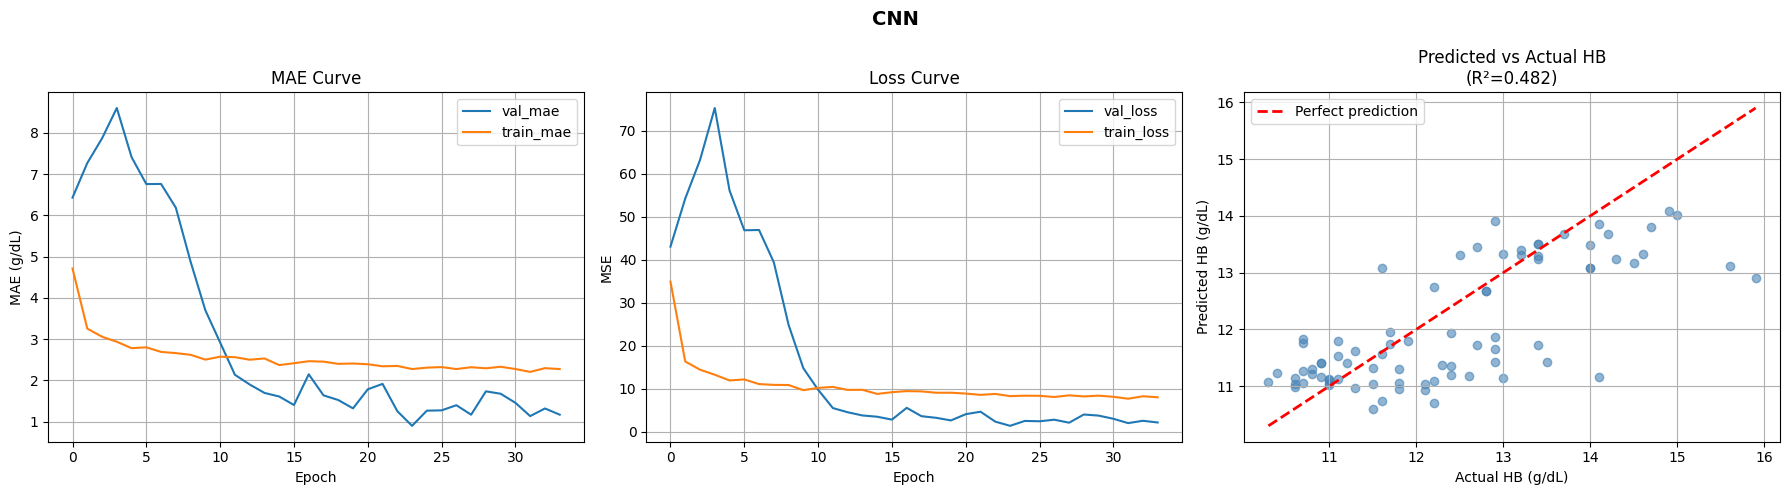

In [21]:
evaluate_regression_model("CNN", model_1_REG, history_1_REG)

## CNN2

In [13]:
model_2_REG = build_models(backbone="cnn2",mode="regression")

In [14]:
model_2_REG.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "mse",
    metrics   = [
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

history_2_REG = model_2_REG.fit(
    x               = [X_palm_train, X_nail_train, X_meta_train],
    y               = y_hb_train,       
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_hb_val),  # ← y_hb_val
    epochs          = 100,
    batch_size      = 32,
    callbacks       = callbacks,
    verbose         = 1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 452s 7s/step - loss: 54.2279 - mae: 6.3251 - rmse: 7.3606 - val_loss: 148.9933 - val_mae: 12.1075 - val_rmse: 12.2043 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 391s 7s/step - loss: 18.9977 - mae: 3.5182 - rmse: 4.3530 - val_loss: 148.6541 - val_mae: 12.1023 - val_rmse: 12.1904 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 369s 6s/step - loss: 14.8103 - mae: 3.0980 - rmse: 3.8420 - val_loss: 141.7399 - val_mae: 11.8149 - val_rmse: 11.9034 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 277s 5s/step - loss: 13.9070 - mae: 2.9574 - rmse: 3.7226 - val_loss: 128.8222 - val_mae: 11.2599 - val_rmse: 11.3478 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 281s 5s/step - loss: 11.6440 - mae: 2.7282 - rmse: 3.4052 - val_loss: 119.9127 - val_mae: 10.8617 - val_rmse: 10.9482 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 287s 5s/step - loss: 11.8344 - mae: 

CNN: Version 2
Metric                 Validation       Test
Loss (MSE)                10.9709     9.8898
MAE                        3.1147     2.9317
RMSE                       3.3051     3.1372
R²                                   -4.3563


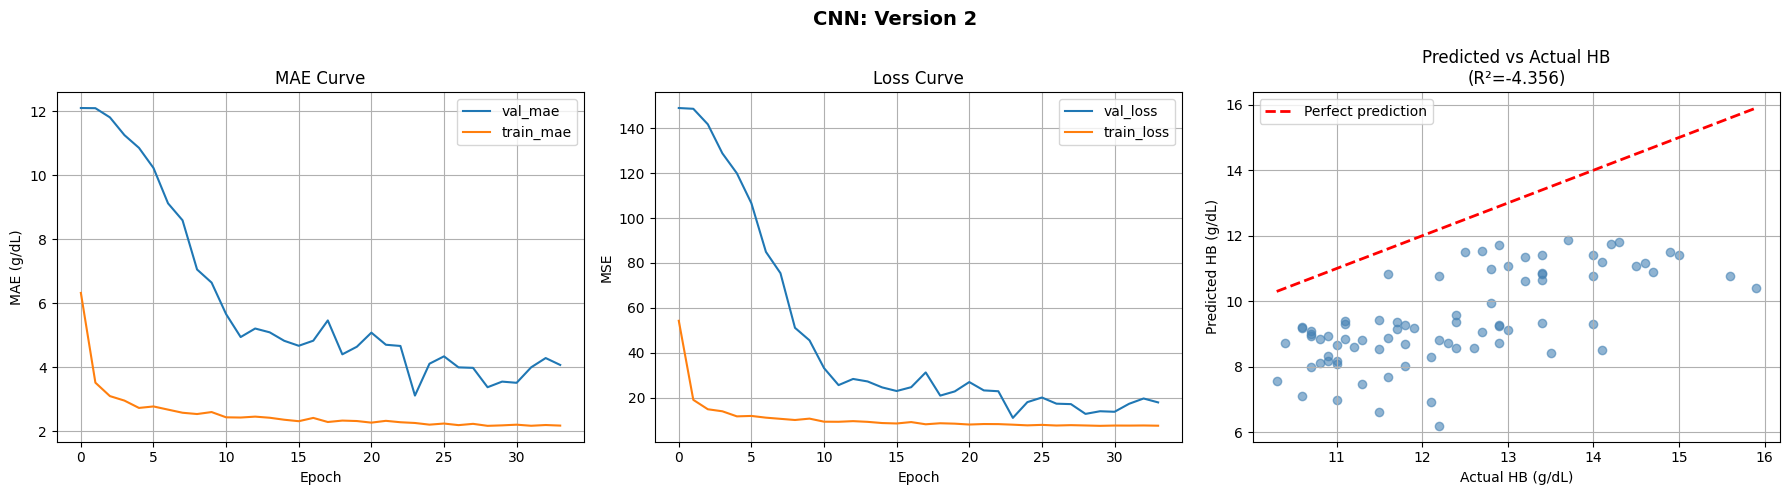

In [15]:
evaluate_regression_model("CNN: Version 2", model_2_REG,  history_2_REG)

## CNN3

In [16]:
model_3_REG = build_models(backbone="cnn3",mode="regression")

In [17]:
model_3_REG.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "mse",
    metrics   = [
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

history_3_REG = model_3_REG.fit(
    x               = [X_palm_train, X_nail_train, X_meta_train],
    y               = y_hb_train,       
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_hb_val),  # ← y_hb_val
    epochs          = 100,
    batch_size      = 32,
    callbacks       = callbacks,
    verbose         = 1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 332s 4s/step - loss: 42.6002 - mae: 5.3172 - rmse: 6.5224 - val_loss: 73.1834 - val_mae: 8.4062 - val_rmse: 8.5513 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 230s 4s/step - loss: 18.4723 - mae: 3.4585 - rmse: 4.2912 - val_loss: 78.5608 - val_mae: 8.7283 - val_rmse: 8.8602 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 231s 4s/step - loss: 16.2054 - mae: 3.2733 - rmse: 4.0184 - val_loss: 78.2388 - val_mae: 8.7213 - val_rmse: 8.8420 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 229s 4s/step - loss: 14.6059 - mae: 3.0773 - rmse: 3.8142 - val_loss: 74.4527 - val_mae: 8.5163 - val_rmse: 8.6253 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 237s 4s/step - loss: 13.1762 - mae: 2.8937 - rmse: 3.6220 - val_loss: 67.5302 - val_mae: 8.1112 - val_rmse: 8.2142 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 237s 4s/step - loss: 12.9123 - mae: 2.8722 - rmse: 

CNN: Version 3
Metric                 Validation       Test
Loss (MSE)                73.1834    69.3326
MAE                        8.4062     8.2061
RMSE                       8.5513     8.3231
R²                                  -36.6999


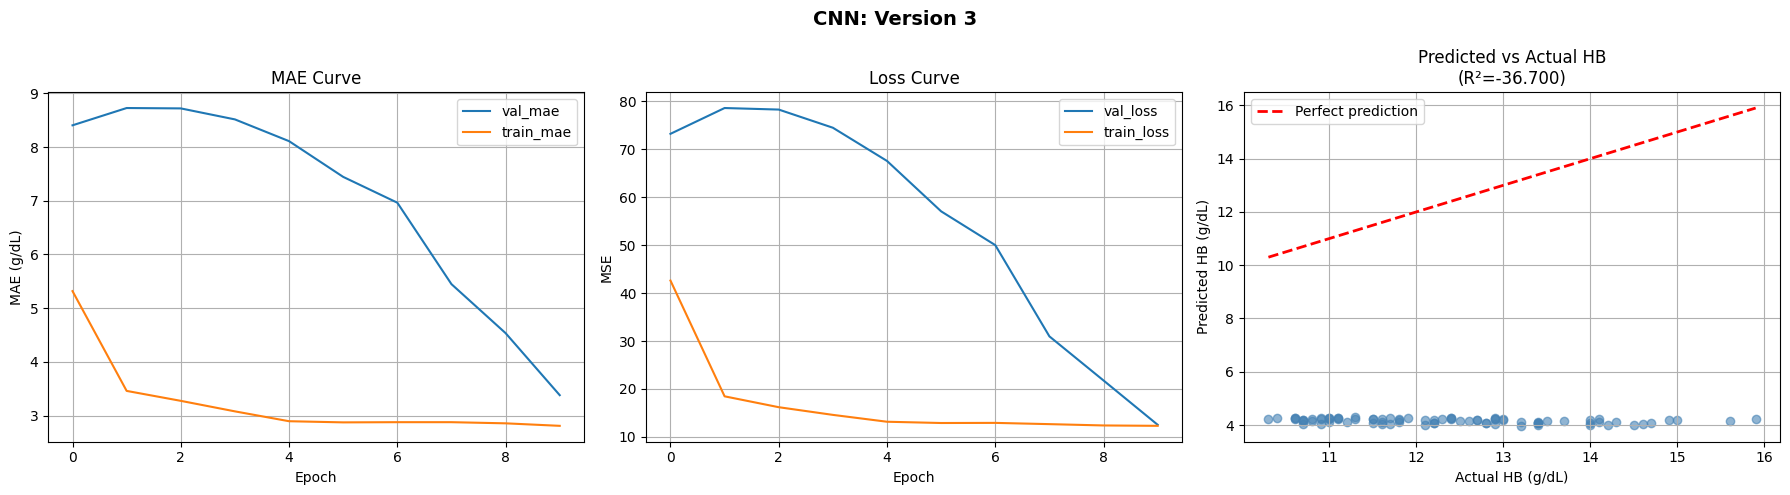

In [18]:
evaluate_regression_model("CNN: Version 3", model_3_REG,  history_3_REG)

## CNN_4

In [19]:
model_4_REG = build_models(backbone="cnn4",mode="regression")

In [20]:
model_4_REG.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "mse",
    metrics   = [
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

history_4_REG = model_4_REG.fit(
    x               = [X_palm_train, X_nail_train, X_meta_train],
    y               = y_hb_train,       
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_hb_val),  # ← y_hb_val
    epochs          = 100,
    batch_size      = 32,
    callbacks       = callbacks,
    verbose         = 1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 83s 867ms/step - loss: 36.5718 - mae: 4.9157 - rmse: 6.0427 - val_loss: 4.0671 - val_mae: 1.5051 - val_rmse: 2.0025 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 48s 825ms/step - loss: 18.5940 - mae: 3.4888 - rmse: 4.3055 - val_loss: 3.2280 - val_mae: 1.3341 - val_rmse: 1.7810 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 48s 824ms/step - loss: 15.8959 - mae: 3.2206 - rmse: 3.9800 - val_loss: 2.8969 - val_mae: 1.2713 - val_rmse: 1.6857 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 47s 814ms/step - loss: 15.1962 - mae: 3.1320 - rmse: 3.8912 - val_loss: 2.8516 - val_mae: 1.2878 - val_rmse: 1.6724 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 49s 835ms/step - loss: 14.3291 - mae: 3.0271 - rmse: 3.7782 - val_loss: 2.6515 - val_mae: 1.2871 - val_rmse: 1.6116 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 47s 814ms/step - loss: 13.5394 - mae: 2.9481 -

CNN: Version 4
Metric                 Validation       Test
Loss (MSE)                 1.4207     1.1108
MAE                        0.9111     0.8234
RMSE                       1.1696     1.0286
R²                                    0.4242


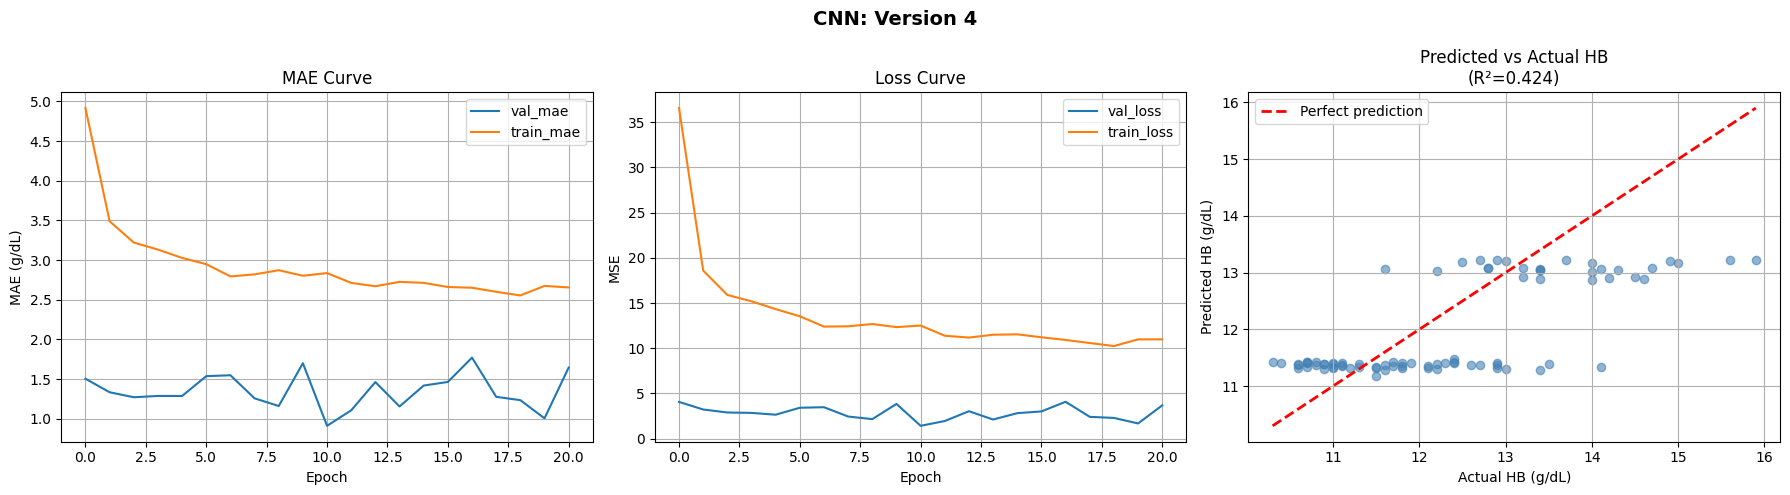

In [21]:
evaluate_regression_model("CNN: Version 4", model_4_REG,  history_4_REG)

## CNN_5

In [22]:
model_5_REG = build_models(backbone="cnn5",mode="regression")

In [23]:
model_5_REG.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "mse",
    metrics   = [
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

history_5_REG = model_5_REG.fit(
    x               = [X_palm_train, X_nail_train, X_meta_train],
    y               = y_hb_train,       
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_hb_val),  # ← y_hb_val
    epochs          = 100,
    batch_size      = 32,
    callbacks       = callbacks,
    verbose         = 1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 316s 5s/step - loss: 57.9661 - mae: 6.5225 - rmse: 7.6098 - val_loss: 3.5525 - val_mae: 1.3958 - val_rmse: 1.8696 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 274s 5s/step - loss: 20.7563 - mae: 3.6891 - rmse: 4.5497 - val_loss: 3.1866 - val_mae: 1.3265 - val_rmse: 1.7693 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 270s 5s/step - loss: 19.4122 - mae: 3.5764 - rmse: 4.3996 - val_loss: 3.1300 - val_mae: 1.3687 - val_rmse: 1.7535 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 271s 5s/step - loss: 16.5641 - mae: 3.2908 - rmse: 4.0631 - val_loss: 3.3258 - val_mae: 1.4906 - val_rmse: 1.8086 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 269s 5s/step - loss: 15.9912 - mae: 3.1864 - rmse: 3.9921 - val_loss: 2.7275 - val_mae: 1.3597 - val_rmse: 1.6350 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 274s 5s/step - loss: 14.4277 - mae: 3.0407 - rmse: 3.791

CNN: Version 5
Metric                 Validation       Test
Loss (MSE)                 1.2340     1.0671
MAE                        0.8553     0.8083
RMSE                       1.0864     1.0067
R²                                    0.4485


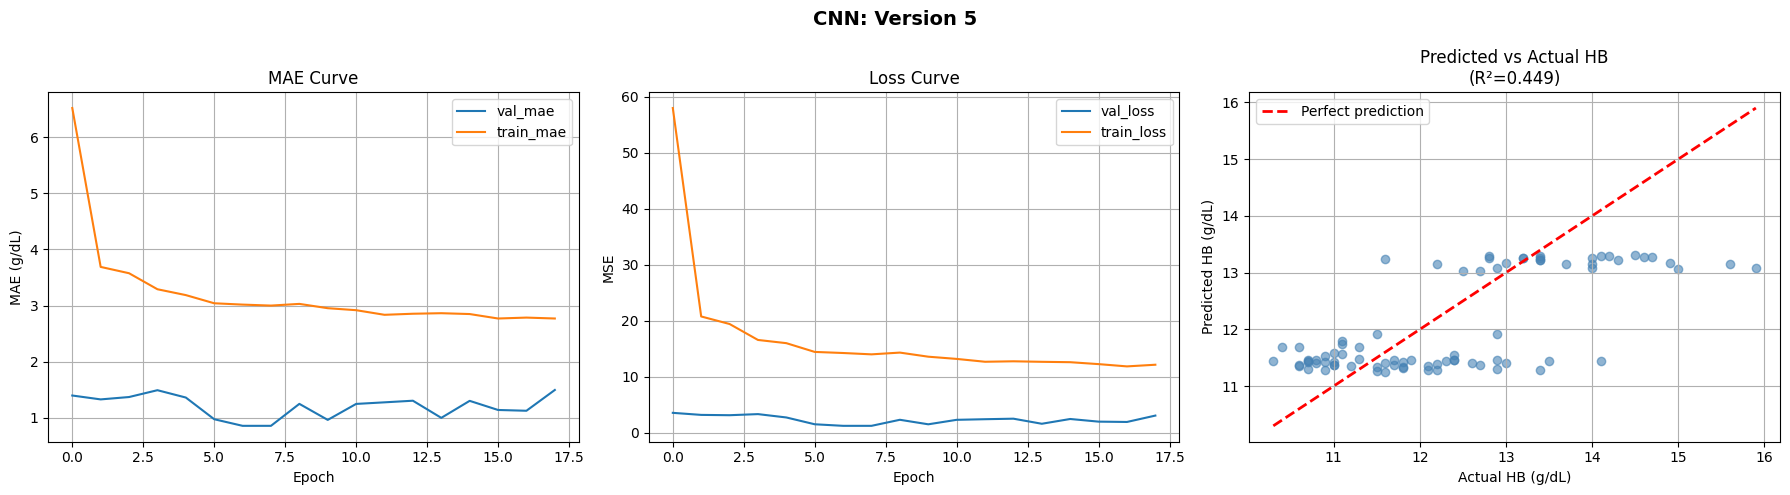

In [24]:
evaluate_regression_model("CNN: Version 5", model_5_REG,  history_5_REG)

## MobileNetV2

In [13]:
model_6_REG = build_models(backbone="mobilenetv2",mode="regression")

In [14]:
model_6_REG.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "mse",
    metrics   = [
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

history_6_REG = model_6_REG.fit(
    x               = [X_palm_train, X_nail_train, X_meta_train],
    y               = y_hb_train,       # ← HB values not labels
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_hb_val),  # ← y_hb_val
    epochs          = 100,
    batch_size      = 32,
    callbacks       = callbacks,
    verbose         = 1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - loss: 55.1909 - mae: 6.1362 - rmse: 7.4251 - val_loss: 8.8447 - val_mae: 2.5473 - val_rmse: 2.9642 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - loss: 19.2669 - mae: 3.5410 - rmse: 4.3828 - val_loss: 6.5298 - val_mae: 2.1793 - val_rmse: 2.5439 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - loss: 16.1372 - mae: 3.2408 - rmse: 4.0099 - val_loss: 2.9666 - val_mae: 1.3343 - val_rmse: 1.7054 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - loss: 14.9741 - mae: 3.1072 - rmse: 3.8621 - val_loss: 2.3556 - val_mae: 1.1756 - val_rmse: 1.5158 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - loss: 14.4040 - mae: 3.0316 - rmse: 3.7876 - val_loss: 1.9469 - val_mae: 1.0560 - val_rmse: 1.3744 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - loss: 13.7189 - mae: 2.9751 - rmse: 3.6961 - v

MobileNet
Metric                 Validation       Test
Loss (MSE)                 1.9469     1.4166
MAE                        1.0560     0.9634
RMSE                       1.3744     1.1657
R²                                    0.2605


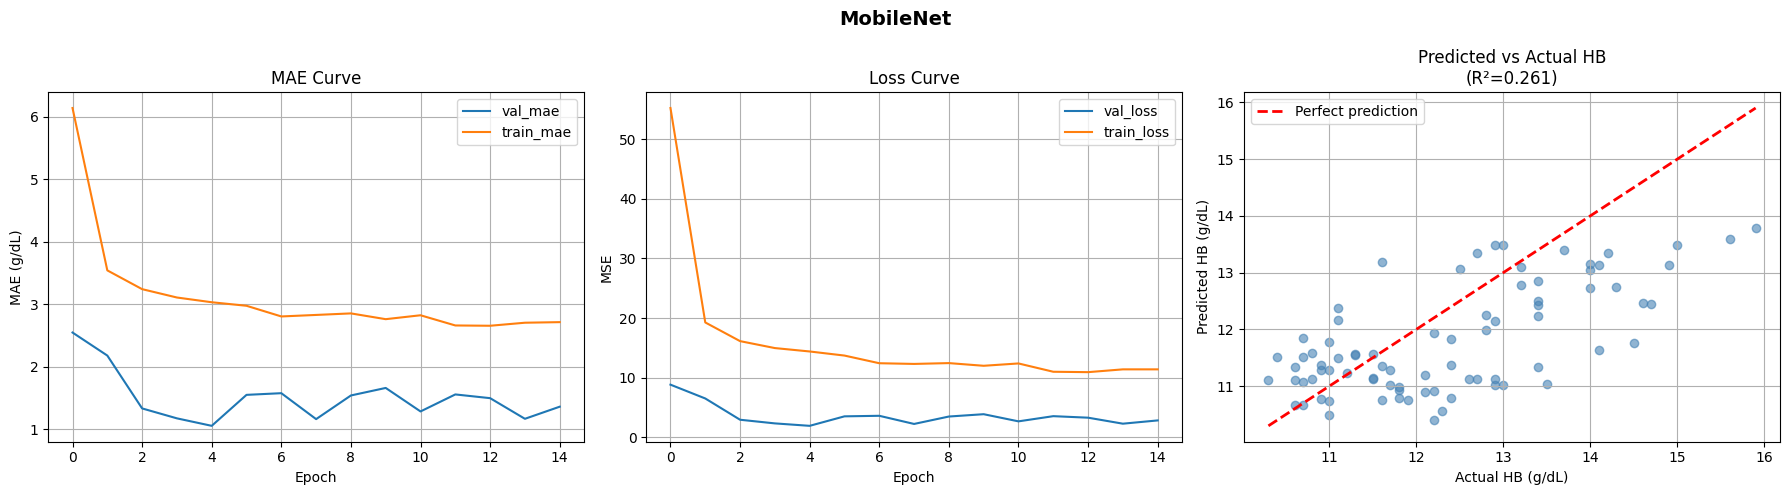

In [15]:
evaluate_regression_model("MobileNet", model_6_REG,  history_6_REG)

## EfficientNetB0

In [16]:
model_7_REG = build_models(backbone="efficientnetb0",mode="regression")

In [17]:
model_7_REG.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4) ,
    loss      = "mse",
    metrics   = [
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

In [18]:
history_7_REG = model_7_REG.fit(
    x               = [X_palm_train, X_nail_train, X_meta_train],
    y               = y_hb_train,       # ← HB values not labels
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_hb_val),  # ← y_hb_val
    epochs          = 100,
    batch_size      = 32,
    callbacks       = callbacks,
    verbose         = 1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 236s 3s/step - loss: 53.7430 - mae: 6.0766 - rmse: 7.3238 - val_loss: 6.5272 - val_mae: 2.0423 - val_rmse: 2.5342 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - loss: 19.7981 - mae: 3.5705 - rmse: 4.4377 - val_loss: 3.4645 - val_mae: 1.3867 - val_rmse: 1.8329 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - loss: 16.7840 - mae: 3.3041 - rmse: 4.0840 - val_loss: 3.9115 - val_mae: 1.5597 - val_rmse: 1.9511 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - loss: 16.4084 - mae: 3.2751 - rmse: 4.0378 - val_loss: 2.7692 - val_mae: 1.2836 - val_rmse: 1.6323 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - loss: 15.5303 - mae: 3.1471 - rmse: 3.9275 - val_loss: 2.4168 - val_mae: 1.1948 - val_rmse: 1.5206 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - loss: 14.7240 - mae: 3.0874 - rmse: 3.823

EfficientNetB0
Metric                 Validation       Test
Loss (MSE)                 1.6298     1.3169
MAE                        0.9638     0.8352
RMSE                       1.2350     1.1011
R²                                    0.3402


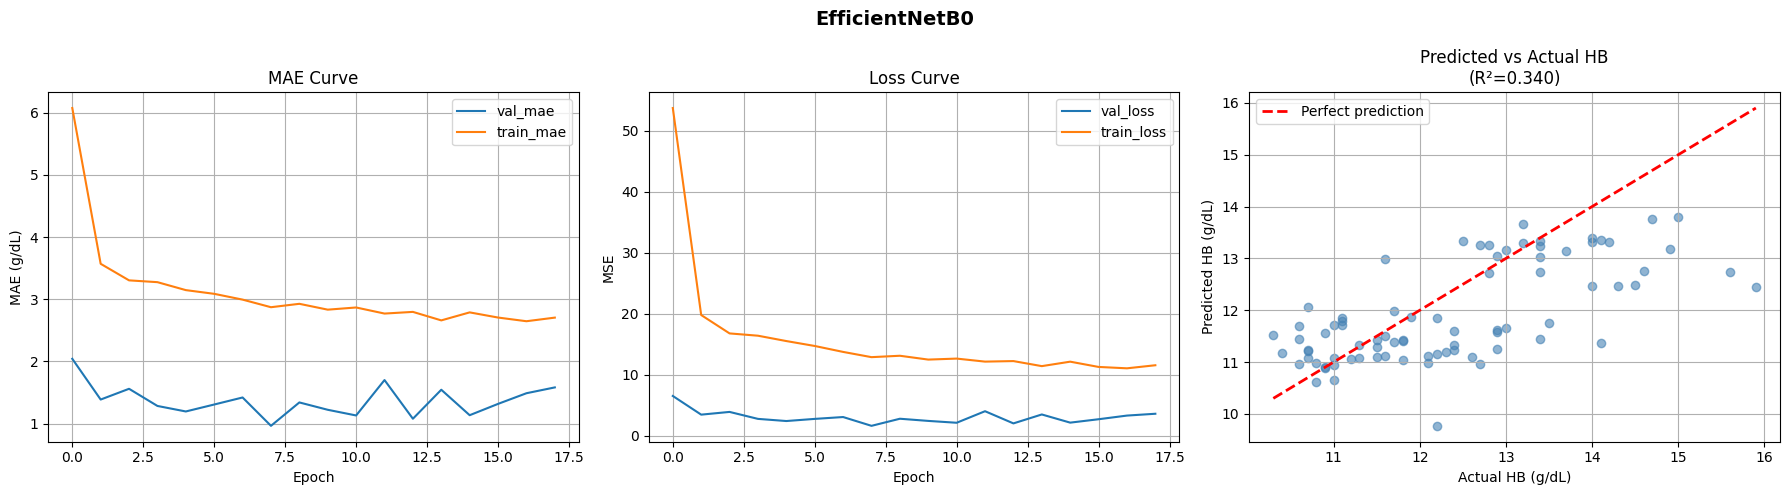

In [19]:
evaluate_regression_model("EfficientNetB0", model_7_REG,  history_7_REG)

## DenseNet121

In [20]:
model_8_REG = build_models(backbone="densenet121",mode="regression")

In [21]:
model_8_REG.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "mse",
    metrics   = [
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

history_8_REG = model_8_REG.fit(
    x               = [X_palm_train, X_nail_train, X_meta_train],
    y               = y_hb_train,       # ← HB values not labels
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_hb_val),  # ← y_hb_val
    epochs          = 100,
    batch_size      = 32,
    callbacks       = callbacks,
    verbose         = 1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 322s 4s/step - loss: 51.8015 - mae: 5.9936 - rmse: 7.1933 - val_loss: 13.6287 - val_mae: 3.2960 - val_rmse: 3.6838 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 152s 3s/step - loss: 16.2598 - mae: 3.2491 - rmse: 4.0251 - val_loss: 5.6257 - val_mae: 1.9017 - val_rmse: 2.3596 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 161s 3s/step - loss: 14.3777 - mae: 3.0461 - rmse: 3.7841 - val_loss: 3.9505 - val_mae: 1.5705 - val_rmse: 1.9729 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 191s 3s/step - loss: 13.2988 - mae: 2.9259 - rmse: 3.6388 - val_loss: 2.7021 - val_mae: 1.2700 - val_rmse: 1.6261 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 172s 3s/step - loss: 12.1644 - mae: 2.7919 - rmse: 3.4794 - val_loss: 3.9945 - val_mae: 1.6676 - val_rmse: 1.9841 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 156s 3s/step - loss: 10.9043 - mae: 2.6313 - rmse: 3.29

DenseNet
Metric                 Validation       Test
Loss (MSE)                 1.4949     1.1611
MAE                        0.9276     0.8607
RMSE                       1.1988     1.0504
R²                                    0.3996


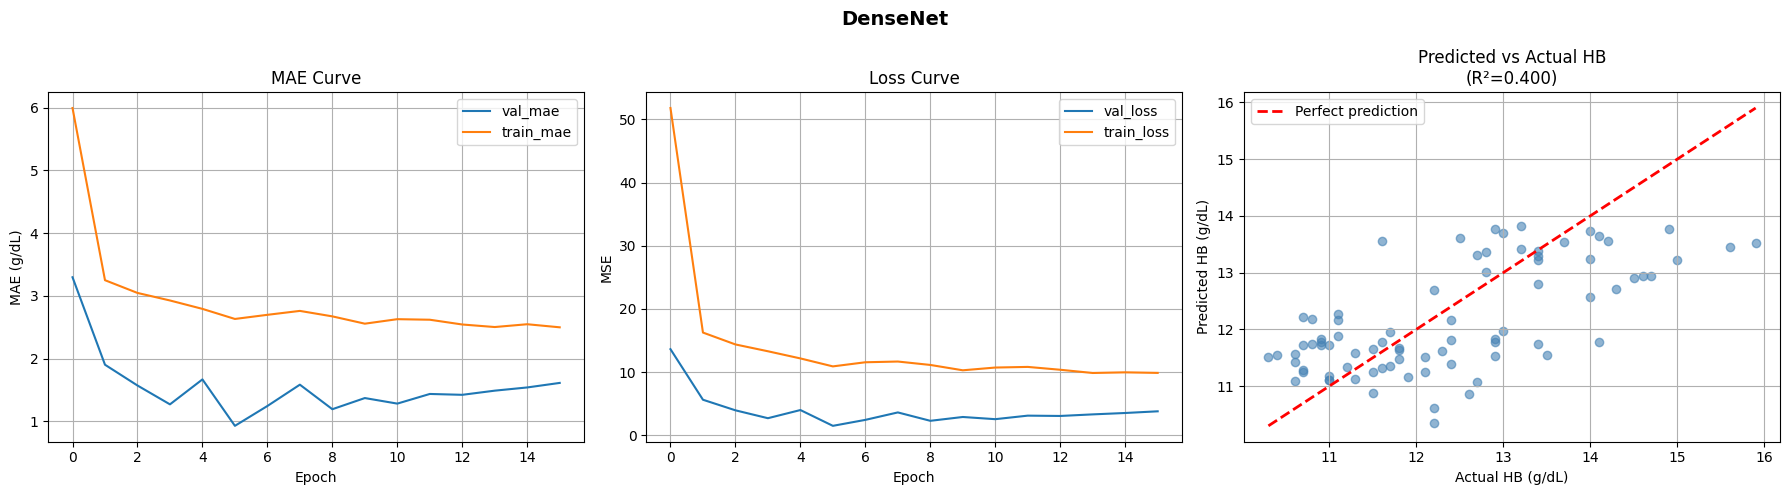

In [22]:
evaluate_regression_model("DenseNet", model_8_REG,  history_8_REG)

## DenseNet169

In [23]:
model_9_REG = build_models(backbone="densenet169",mode="regression")

In [24]:
model_9_REG.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "mse",
    metrics   = [
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

history_9_REG = model_9_REG.fit(
    x               = [X_palm_train, X_nail_train, X_meta_train],
    y               = y_hb_train,       
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_hb_val),  # ← y_hb_val
    epochs          = 100,
    batch_size      = 32,
    callbacks       = callbacks,
    verbose         = 1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 235s 3s/step - loss: 40.7185 - mae: 5.2441 - rmse: 6.3765 - val_loss: 10.8444 - val_mae: 2.9952 - val_rmse: 3.2842 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 189s 3s/step - loss: 18.5240 - mae: 3.4640 - rmse: 4.2972 - val_loss: 4.5871 - val_mae: 1.7904 - val_rmse: 2.1281 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 187s 3s/step - loss: 15.7162 - mae: 3.1689 - rmse: 3.9570 - val_loss: 5.0393 - val_mae: 1.9175 - val_rmse: 2.2319 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 191s 3s/step - loss: 13.3078 - mae: 2.9168 - rmse: 3.6400 - val_loss: 3.1949 - val_mae: 1.4155 - val_rmse: 1.7711 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 190s 3s/step - loss: 12.5697 - mae: 2.8703 - rmse: 3.5372 - val_loss: 3.2057 - val_mae: 1.4230 - val_rmse: 1.7742 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 187s 3s/step - loss: 12.1516 - mae: 2.7797 - rmse: 3.47

DenseNet169
Metric                 Validation       Test
Loss (MSE)                10.8444     9.2836
MAE                        2.9952     2.7727
RMSE                       3.2842     3.0373
R²                                   -4.0205


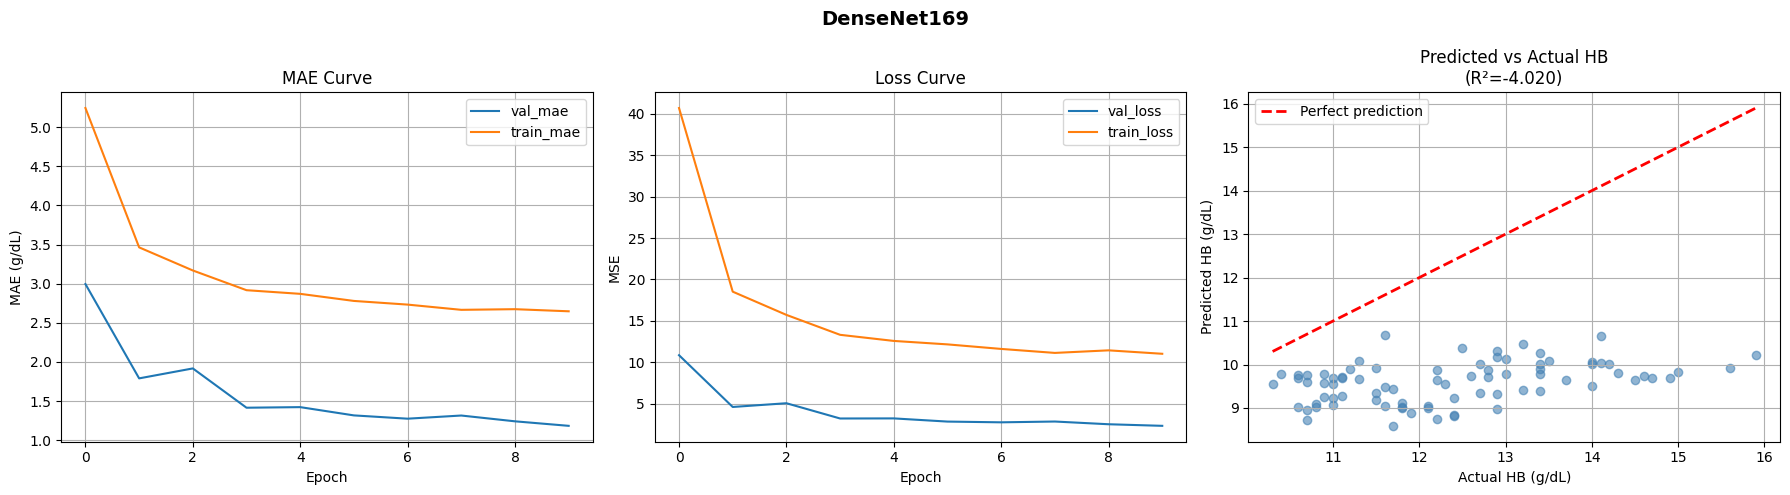

In [25]:
evaluate_regression_model("DenseNet169", model_9_REG,  history_9_REG)

## ResNet50

In [26]:
model_10_REG = build_models(backbone="resnet50",mode="regression")

In [27]:
model_10_REG.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = "mse",
    metrics   = [
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

history_10_REG = model_10_REG.fit(
    x               = [X_palm_train, X_nail_train, X_meta_train],
    y               = y_hb_train,       
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_hb_val),  # ← y_hb_val
    epochs          = 100,
    batch_size      = 32,
    callbacks       = callbacks,
    verbose         = 1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 253s 4s/step - loss: 64.8490 - mae: 6.9923 - rmse: 8.0493 - val_loss: 8.2034 - val_mae: 2.4352 - val_rmse: 2.8540 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 226s 4s/step - loss: 20.3981 - mae: 3.6222 - rmse: 4.5100 - val_loss: 6.9085 - val_mae: 2.2755 - val_rmse: 2.6173 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 222s 4s/step - loss: 17.3320 - mae: 3.3705 - rmse: 4.1562 - val_loss: 3.7456 - val_mae: 1.6089 - val_rmse: 1.9203 - learning_rate: 1.0000e-04
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 225s 4s/step - loss: 15.3424 - mae: 3.1377 - rmse: 3.9095 - val_loss: 2.1902 - val_mae: 1.1060 - val_rmse: 1.4603 - learning_rate: 1.0000e-04
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 220s 4s/step - loss: 15.1676 - mae: 3.1229 - rmse: 3.8871 - val_loss: 2.8554 - val_mae: 1.3431 - val_rmse: 1.6726 - learning_rate: 1.0000e-04
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 220s 4s/step - loss: 13.6611 - mae: 2.9739 - rmse: 3.688

ResNet50
Metric                 Validation       Test
Loss (MSE)                 8.2034     7.0355
MAE                        2.4352     2.2609
RMSE                       2.8540     2.6415
R²                                   -2.7971


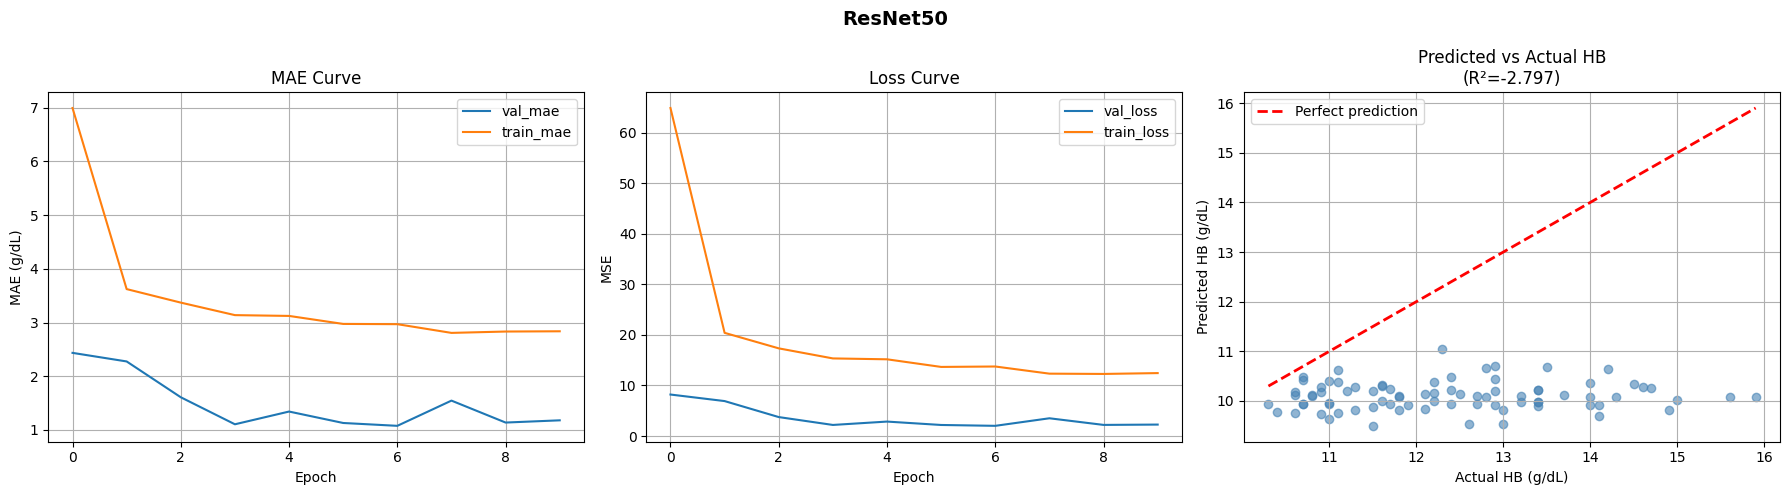

In [28]:
evaluate_regression_model("ResNet50", model_10_REG,  history_10_REG)

# Other Experiments

## EfficientNetB0 trained with normalized HB

In [ ]:
hb_mean = y_hb_train.mean()
hb_std  = y_hb_train.std()

y_hb_train_norm = (y_hb_train - hb_mean) / hb_std
y_hb_val_norm   = (y_hb_val   - hb_mean) / hb_std
y_hb_test_norm  = (y_hb_test  - hb_mean) / hb_std

print(f"HB mean : {hb_mean:.4f} | HB std : {hb_std:.4f}")

HB mean : 12.2889 | HB std : 1.3660


In [36]:
history_reg = model_4_REG.fit(
    x               = [X_palm_train, X_nail_train, X_meta_train],
    y               = y_hb_train_norm,
    validation_data = ([X_palm_val, X_nail_val, X_meta_val], y_hb_val_norm),
    epochs=100, batch_size=32,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - loss: 0.8094 - mae: 1.1605 - rmse: 1.4360 - val_loss: 0.6895 - val_mae: 1.0650 - val_rmse: 1.2052 - learning_rate: 1.0000e-06
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - loss: 0.7222 - mae: 1.0709 - rmse: 1.3195 - val_loss: 0.6831 - val_mae: 1.0473 - val_rmse: 1.2224 - learning_rate: 1.0000e-06
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - loss: 0.6971 - mae: 1.0365 - rmse: 1.2924 - val_loss: 0.6767 - val_mae: 1.0277 - val_rmse: 1.2354 - learning_rate: 1.0000e-06
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - loss: 0.6469 - mae: 0.9846 - rmse: 1.2246 - val_loss: 0.6506 - val_mae: 0.9838 - val_rmse: 1.2186 - learning_rate: 1.0000e-06
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - loss: 0.6412 - mae: 0.9732 - rmse: 1.2210 - val_loss: 0.6277 - val_mae: 0.9476 - val_rmse: 1.2038 - learning_rate: 1.0000e-06
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - loss: 0.6043 - mae: 0.9323 - rmse: 1.1743 - val_los

MAE  : 0.7986 g/dL
RMSE : 0.9801 g/dL
R²   : 0.4772


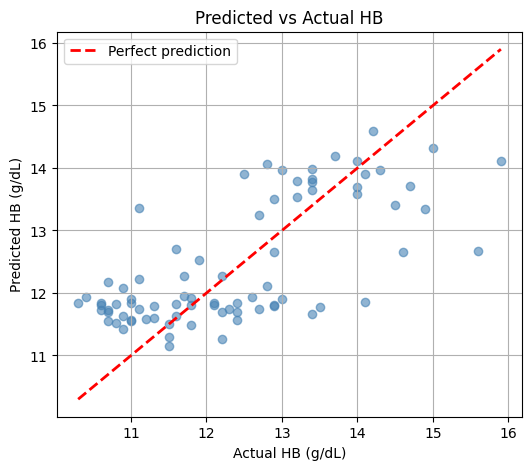

In [37]:
# predict and denormalize
y_pred_norm   = model_4_REG.predict([X_palm_test, X_nail_test, X_meta_test], verbose=0).ravel()
y_pred_actual = (y_pred_norm * hb_std) + hb_mean  # ← back to g/dL

# evaluate on actual values
print(f"MAE  : {mean_absolute_error(y_hb_test, y_pred_actual):.4f} g/dL")
print(f"RMSE : {np.sqrt(mean_squared_error(y_hb_test, y_pred_actual)):.4f} g/dL")
print(f"R²   : {r2_score(y_hb_test, y_pred_actual):.4f}")

# scatter plot
plt.figure(figsize=(6, 5))
plt.scatter(y_hb_test, y_pred_actual, alpha=0.6, color="steelblue")
plt.plot([y_hb_test.min(), y_hb_test.max()],
         [y_hb_test.min(), y_hb_test.max()],
         "r--", lw=2, label="Perfect prediction")
plt.title(f"Predicted vs Actual HB")
plt.xlabel("Actual HB (g/dL)")
plt.ylabel("Predicted HB (g/dL)")
plt.legend()
plt.grid(True)
plt.show()